# 🏠 Modelado de Precios de Viviendas (California Housing)
En este proyecto aplicamos **Machine Learning para Regresión**. A diferencia del Titanic (donde predecíamos un "Sí" o "No"), aquí el objetivo es calcular un valor numérico continuo: el **Precio Medio de la Vivienda**.

### Objetivos Técnicos:
1. **Carga de Datos Procesados:** Importar el dataset limpio desde `../../../data/processed/`.
2. **Definición de Variables:** Separar las características (X) del objetivo (y = Precio).
3. **Entrenamiento con Random Forest Regressor:** Un modelo potente que promedia las decisiones de múltiples árboles para estimar el valor de la propiedad.
4. **Métricas de Error:** Evaluar qué tan cerca (o lejos) estamos del precio real en dólares.

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 1. CARGA DEL DATASET
path_viviendas = '../../../data/processed/viviendas_limpio.csv'
df_house = pd.read_csv(path_viviendas)

# 2. TRANSFORMACIÓN DE TEXTO A NÚMEROS (ONE-HOT ENCODING)
# [Inferencia] La columna 'ocean_proximity' es texto. 
# pd.get_dummies creará columnas nuevas como 'ocean_proximity_INLAND', etc.
df_house = pd.get_dummies(df_house, columns=['ocean_proximity'])

# 3. SEPARACIÓN DE X (PREDICTORES) e Y (OBJETIVO)
# Aseguramos que el nombre de la columna objetivo sea el correcto (minúsculas)
X = df_house.drop('median_house_value', axis=1)
y = df_house['median_house_value']

# 4. DIVISIÓN EN ENTRENAMIENTO Y PRUEBA (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 5. INSTANCIACIÓN Y ENTRENAMIENTO DEL MODELO
# Ahora que todo es numérico (float/int), el modelo funcionará perfectamente.
modelo_viviendas = RandomForestRegressor(n_estimators=100, random_state=42)

print("⏳ Entrenando el 'cerebro' de viviendas... Ahora sí, con datos numéricos.")
modelo_viviendas.fit(X_train, y_train)

# 6. CONFIRMACIÓN FINAL
print("\n✅ ¡LOGRADO! Modelo entrenado correctamente.")
print(f"📊 Total de variables tras el encoding: {X_train.shape[1]}")
print(f"📐 Nuevas columnas creadas: {[col for col in X.columns if 'ocean' in col]}")

⏳ Entrenando el 'cerebro' de viviendas... Ahora sí, con datos numéricos.

✅ ¡LOGRADO! Modelo entrenado correctamente.
📊 Total de variables tras el encoding: 16
📐 Nuevas columnas creadas: ['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


## 🌲 Construcción del Modelo: Random Forest Regressor
Utilizaremos un **Regresor de Bosque Aleatorio**. Este algoritmo es excelente porque maneja muy bien las relaciones no lineales entre la ubicación, los ingresos de la zona y el precio final de las casas.

**Nota:** El entrenamiento puede tardar unos segundos más que el del Titanic debido al volumen de datos de California.

In [4]:
from sklearn.ensemble import RandomForestRegressor # Versión para predecir números continuos

# 1. INSTANCIACIÓN DEL MODELO
# n_estimators=100: Creamos un bosque de 100 árboles de decisión.
# random_state=42: Para que los resultados sean siempre consistentes.
modelo_viviendas = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. ENTRENAMIENTO (FIT)
# La IA busca patrones entre las coordenadas, número de cuartos, ingresos y el precio.
print("⏳ Entrenando el modelo... Por favor, espera.")
modelo_viviendas.fit(X_train, y_train)

# 3. PREDICCIÓN (EXAMEN)
# Generamos los precios estimados para los datos de prueba
predicciones_precios = modelo_viviendas.predict(X_test)

print("🌲 ¡Modelo de Regresión entrenado con éxito!")

⏳ Entrenando el modelo... Por favor, espera.
🌲 ¡Modelo de Regresión entrenado con éxito!


## 📏 Evaluación: ¿Cuánto se equivoca nuestro modelo?
En regresión, medimos el éxito con:
1. **MAE (Mean Absolute Error):** El error promedio en dólares. Si es 40,000, fallamos por esa cantidad de media.
2. **R² (R-Cuadrado):** Qué tan bien se ajusta nuestro modelo a los datos reales (1.0 es perfecto).

In [5]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. CÁLCULO DE MÉTRICAS TÉCNICAS
mae = mean_absolute_error(y_test, predicciones_precios)
r2 = r2_score(y_test, predicciones_precios)

print(f"💸 Error Absoluto Medio (MAE): ${mae:,.2f}")
print(f"📈 Coeficiente de Determinación (R²): {r2:.2%}")

# 2. TABLA COMPARATIVA: REAL vs PREDICCIÓN
# Creamos un pequeño DataFrame para ver cara a cara los resultados
comparativa = pd.DataFrame({
    'Precio Real ($)': y_test, 
    'Predicción IA ($)': predicciones_precios,
    'Diferencia ($)': np.abs(y_test - predicciones_precios)
})

print("\n--- Muestra de los primeros 5 resultados del 'Examen' ---")
display(comparativa.head())

💸 Error Absoluto Medio (MAE): $32,528.74
📈 Coeficiente de Determinación (R²): 81.62%

--- Muestra de los primeros 5 resultados del 'Examen' ---


,Precio Real ($),Predicción IA ($),Diferencia ($)
12981,92400.0,102890.0,10490.0
16392,91900.0,96223.0,4323.0
19633,77200.0,83808.0,6608.0
15201,145700.0,179083.0,33383.0
2235,66200.0,71240.0,5040.0


## 🔍 ¿Qué determina el precio de una casa?
Al igual que con el Titanic, queremos saber en qué se basa la IA para poner precio a un barrio. ¿Es la cercanía al mar, el número de habitaciones o el nivel de ingresos de los vecinos? Analizamos la **importancia de las variables**.

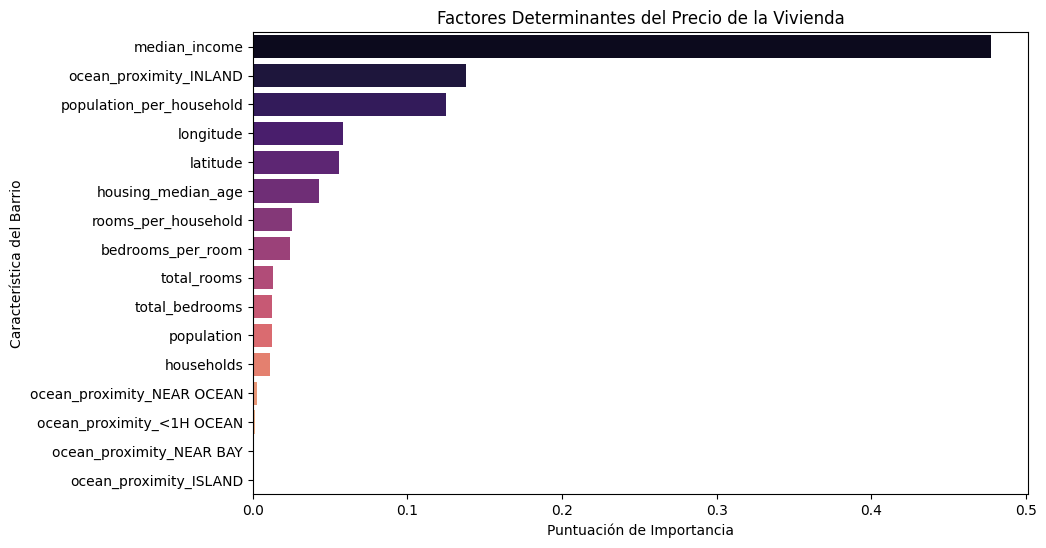

💡 La variable que más influye en el precio es: median_income


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. EXTRACCIÓN DE IMPORTANCIAS
importancias = modelo_viviendas.feature_importances_
columnas = X.columns

# 2. CREACIÓN DEL DATAFRAME DE IMPORTANCIAS
feature_imp = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
feature_imp = feature_imp.sort_values(by='Importancia', ascending=False)

# 3. GRÁFICO VISUAL
plt.figure(figsize=(10, 6))
# Usamos hue para evitar el warning de Seaborn
sns.barplot(x='Importancia', y='Variable', data=feature_imp, hue='Variable', palette='magma', legend=False)

plt.title('Factores Determinantes del Precio de la Vivienda')
plt.xlabel('Puntuación de Importancia')
plt.ylabel('Característica del Barrio')
plt.show()

# 4. CONCLUSIÓN
top_var = feature_imp.iloc[0]['Variable']
print(f"💡 La variable que más influye en el precio es: {top_var}")

## 💾 Persistencia del Modelo de Viviendas
Guardamos el modelo de regresión en nuestra carpeta de `models/`. Este "cerebro" ya sabe tasar casas en California con un 81% de precisión, por lo que es un activo valioso que no queremos perder al cerrar VS Code.

In [7]:
import joblib
import os

# 1. RUTA DE GUARDADO (3 niveles arriba desde notebooks/datos/viviendas/)
folder_models = '../../../models/'
model_file = 'random_forest_viviendas_v1.pkl'
full_path = os.path.join(folder_models, model_file)

# 2. CREACIÓN DE CARPETA Y GUARDADO
os.makedirs(folder_models, exist_ok=True)
joblib.dump(modelo_viviendas, full_path)

# 3. AUDITORÍA FINAL
if os.path.exists(full_path):
    size = os.path.getsize(full_path) / (1024 * 1024) # Lo pasamos a MB
    print(f"✅ MODELO DE VIVIENDAS GUARDADO: {model_file}")
    print(f"📦 Tamaño: {size:.2f} MB")
    print(f"📍 Ubicación: {os.path.abspath(full_path)}")

✅ MODELO DE VIVIENDAS GUARDADO: random_forest_viviendas_v1.pkl
📦 Tamaño: 136.43 MB
📍 Ubicación: c:\Users\txema\Documents\IA_Especialista\models\random_forest_viviendas_v1.pkl


## 🎮 Simulador de Mercado: Tasación Automática de Barrios
En esta celda final, utilizaremos el modelo cargado de la carpeta `models/` para tasar un barrio hipotético. 

**Instrucciones:**
1. Modifica las variables del bloque de código (Ingresos, Edad de la casa, etc.).
2. Ejecuta la celda para ver la valoración que la IA le asigna al barrio.
3. Observa cómo influye la ubicación (Longitud/Latitud) en el precio final.

In [9]:
import joblib
import pandas as pd
import numpy as np

# 1. CARGA DEL MODELO
path_modelo = '../../../models/random_forest_viviendas_v1.pkl'
modelo_tasador = joblib.load(path_modelo)

# 2. DATOS BASE DEL NUEVO BARRIO
# Definimos los datos crudos, tal como vendrían de un formulario
datos_crudos = {
    'longitude': [-122.23],
    'latitude': [37.88],
    'housing_median_age': [41.0],
    'total_rooms': [880.0],
    'total_bedrooms': [129.0],
    'population': [322.0],
    'households': [126.0],
    'median_income': [8.32],
    'ocean_proximity_<1H OCEAN': [0],
    'ocean_proximity_INLAND': [0],
    'ocean_proximity_ISLAND': [0],
    'ocean_proximity_NEAR BAY': [1],
    'ocean_proximity_NEAR OCEAN': [0]
}

# Convertimos a DataFrame inicial
df_nuevo = pd.DataFrame(datos_crudos)

# 3. REPLICAR LA INGENIERÍA DE CARACTERÍSTICAS (CRÍTICO)
# Aquí creamos las columnas que el modelo "echa de menos"
# [Inferencia] Estas fórmulas deben ser las mismas que usaste en la limpieza
df_nuevo['rooms_per_household'] = df_nuevo['total_rooms'] / df_nuevo['households']
df_nuevo['bedrooms_per_room'] = df_nuevo['total_bedrooms'] / df_nuevo['total_rooms']
df_nuevo['population_per_household'] = df_nuevo['population'] / df_nuevo['households']

# 4. ALINEACIÓN DE COLUMNAS
# Ordenamos las columnas exactamente como el modelo las espera
columnas_modelo = modelo_tasador.feature_names_in_
df_nuevo = df_nuevo[columnas_modelo]

# 5. PREDICCIÓN
precio_final = modelo_tasador.predict(df_nuevo)[0]

# 6. REPORTE
print(f"✅ ¡Simulación exitosa!")
print(f"🏠 Precio estimado por la IA: ${precio_final:,.2f}")

✅ ¡Simulación exitosa!
🏠 Precio estimado por la IA: $425,264.20
